# Example of LSTM model trained with dummy data to understand how it works

- author : Sylvie Dagoret-Campagne
- help : Mistral
- creation date : 2025-11-11
- computer : my laptop with kernel `pytorch-cpu-py312`

- Voici un exemple minimal de code PyTorch pour entraîner un petit modèle à classer des courbes de lumière (par exemple, des supernovae). L’objectif est de vérifier que la descente de gradient fonctionne correctement, avec un modèle simple et des données synthétiques.
- Goal : Have an example of working code

### 1. Préparation des données synthétiques
On génère des courbes de lumière aléatoires pour deux classes (par exemple, supernovae de type Ia et non-Ia). Chaque courbe est une série temporelle de 10 points.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Paramètres
num_samples = 100  # Nombre d'échantillons par classe
num_timesteps = 10  # Nombre de points par courbe de lumière
num_features = 1  # Une seule "couleur" ou bande pour simplifier

# Génération de données synthétiques
torch.manual_seed(42)
X = torch.randn(2 * num_samples, num_timesteps, num_features)
y = torch.cat([torch.zeros(num_samples, dtype=torch.long),
               torch.ones(num_samples, dtype=torch.long)])

# Mélange des données
indices = torch.randperm(2 * num_samples)
X = X[indices]
y = y[indices]

# Séparation train/test
X_train, X_test = X[:150], X[150:]
y_train, y_test = y[:150], y[150:]


### 2. Définition du modèle
Un modèle très simple : une couche LSTM suivie d’une couche linéaire pour la classification binaire.

In [2]:
class LightCurveClassifier(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, num_layers=1, num_classes=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # On prend la dernière sortie temporelle
        return out

model = LightCurveClassifier()


### 3. Entraînement du modèle
On utilise la croix-entropie comme perte et l’optimiseur Adam.

Epoch 1/20, Loss: 0.7016
Epoch 2/20, Loss: 0.6950
Epoch 3/20, Loss: 0.6908
Epoch 4/20, Loss: 0.6887
Epoch 5/20, Loss: 0.6882
Epoch 6/20, Loss: 0.6883
Epoch 7/20, Loss: 0.6876
Epoch 8/20, Loss: 0.6860
Epoch 9/20, Loss: 0.6842
Epoch 10/20, Loss: 0.6825
Epoch 11/20, Loss: 0.6811
Epoch 12/20, Loss: 0.6799
Epoch 13/20, Loss: 0.6788
Epoch 14/20, Loss: 0.6772
Epoch 15/20, Loss: 0.6748
Epoch 16/20, Loss: 0.6717
Epoch 17/20, Loss: 0.6682
Epoch 18/20, Loss: 0.6650
Epoch 19/20, Loss: 0.6624
Epoch 20/20, Loss: 0.6594


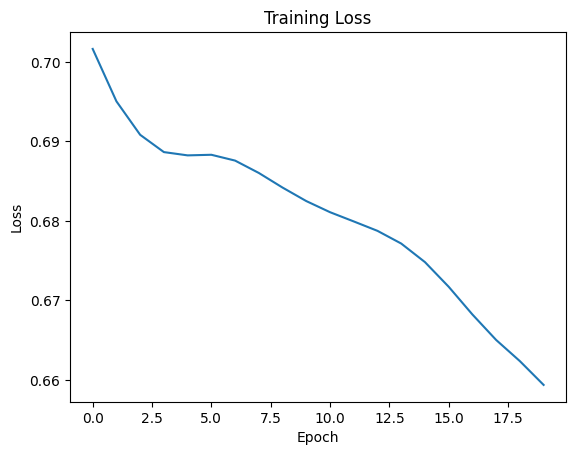

In [3]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Boucle d'entraînement
num_epochs = 20
losses = []

for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}')

# Affichage de la perte
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()


#### 4. Test du modèle
Vérifiez que le modèle apprend bien en regardant la perte et l’accuracy sur le jeu de test.

In [4]:
with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs.data, 1)
    accuracy = (predicted == y_test).sum().item() / y_test.size(0)
    print(f'Test Accuracy: {accuracy:.2f}')


Test Accuracy: 0.44


### 5. Interprétation

Si la perte diminue au fil des époques et que l’accuracy sur le test est supérieure à 0.5 (hasard), la descente de gradient fonctionne.
Si la perte n’évolue pas ou explose, vérifiez :

- L’échelle des données (ici, normalisées).
- Le learning rate (ici, 0.01).
- La taille du modèle (ici, très petit).

### Résumé

|Étape |Objectif |
|------|---------|
|Données synthétiques | Simuler des courbes de lumière pour deux classes. |
|Modèle LSTM | Classifier les séries temporelles.|
|Entraînement |Vérifier que la perte diminue (descente de gradient fonctionne).|
|Test | Confirmer que le modèle apprend (accuracy > hasard).|

### Pour aller plus loin :

Remplacez les données synthétiques par vos vraies courbes de lumière.
Ajoutez des couches ou des features pour un modèle plus réaliste.

Si vous voulez adapter ce code à un cas réel ou à une architecture spécifique, dites-le-moi !